In [18]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

from tensorflow.keras.utils import to_categorical

In [19]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)

(60000, 28, 28)


In [20]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [21]:
cnn = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        10,
        activation='softmax'
    )
])

cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history_cnn = cnn.fit(
    X_train,
    y_train_cat,

    epochs=10,

    validation_split=0.2,

    batch_size=128,

    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9313 - loss: 0.2388 - val_accuracy: 0.9774 - val_loss: 0.0777
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9794 - loss: 0.0664 - val_accuracy: 0.9837 - val_loss: 0.0562
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9857 - loss: 0.0461 - val_accuracy: 0.9872 - val_loss: 0.0431
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9885 - loss: 0.0357 - val_accuracy: 0.9877 - val_loss: 0.0411
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9915 - loss: 0.0276 - val_accuracy: 0.9861 - val_loss: 0.0473
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9936 - loss: 0.0207 - val_accuracy: 0.9874 - val_loss: 0.0416
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9943 - loss: 0.0181 - val_accuracy: 0.9872 - val_loss: 0.0437
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9951 - loss: 0.0149 - 

In [24]:
cnn_loss, cnn_acc = cnn.evaluate(
    X_test,
    y_test_cat
)

print("CNN Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9893 - loss: 0.0340
CNN Accuracy: 0.989300012588501


In [25]:
fnn = Sequential([

    Flatten(
        input_shape=(28,28,1)
    ),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        10,
        activation='softmax'
    )
])

fnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history_fnn = fnn.fit(
    X_train,
    y_train_cat,

    epochs=10,

    validation_split=0.2,

    batch_size=128,

    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8968 - loss: 0.3704 - val_accuracy: 0.9486 - val_loss: 0.1837
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9561 - loss: 0.1504 - val_accuracy: 0.9620 - val_loss: 0.1366
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9696 - loss: 0.1034 - val_accuracy: 0.9647 - val_loss: 0.1155
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9771 - loss: 0.0778 - val_accuracy: 0.9683 - val_loss: 0.1052
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0626 - val_accuracy: 0.9699 - val_loss: 0.0990
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9843 - loss: 0.0513 - val_accuracy: 0.9709 - val_loss: 0.1010
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9888 - loss: 0.0387 - val_accuracy: 0.9725 - val_loss: 0.0933
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9895 - loss: 0.0351 - val_accuracy: 0.

In [27]:
fnn_loss, fnn_acc = fnn.evaluate(
    X_test,
    y_test_cat
)

print("FNN Accuracy:", fnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.0773
FNN Accuracy: 0.9771999716758728


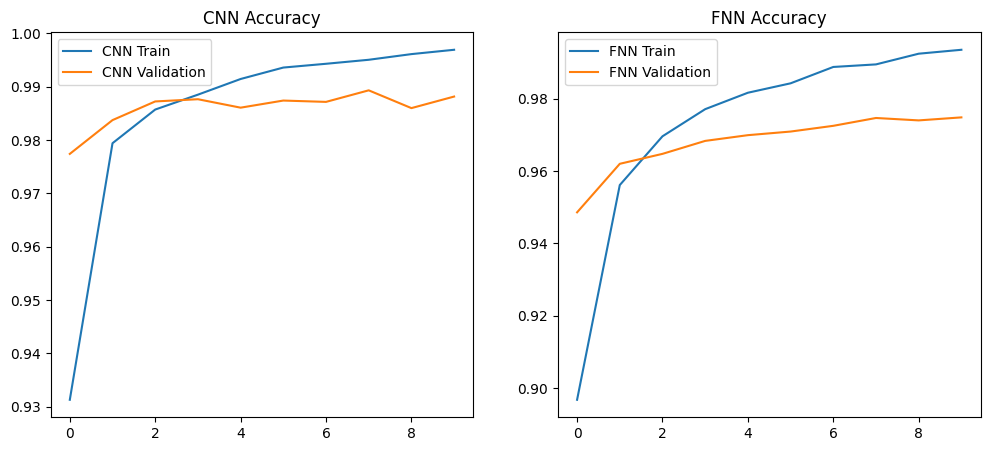

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history_cnn.history['accuracy'],
    label='CNN Train'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='CNN Validation'
)

plt.title("CNN Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history_fnn.history['accuracy'],
    label='FNN Train'
)

plt.plot(
    history_fnn.history['val_accuracy'],
    label='FNN Validation'
)

plt.title("FNN Accuracy")

plt.legend()

plt.show()

In [29]:
filters, biases = cnn.layers[0].get_weights()

print(filters.shape)

(3, 3, 1, 32)


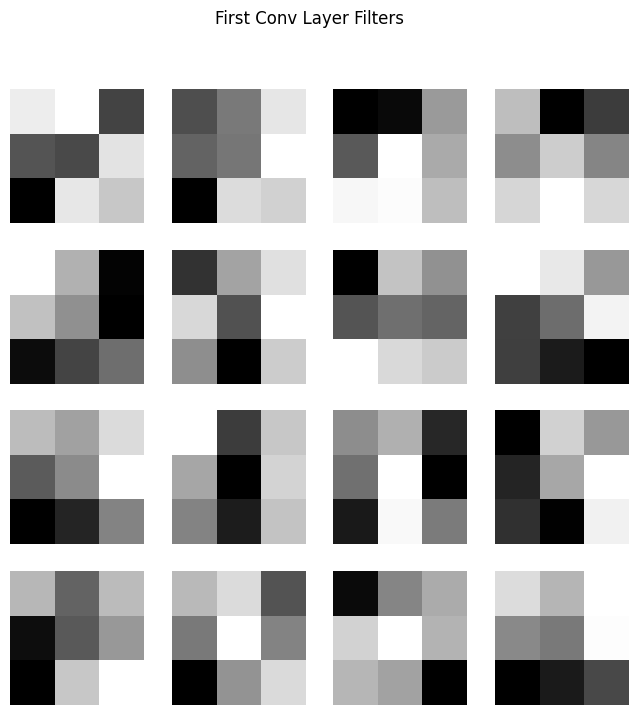

In [30]:
plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        filters[:,:,0,i],
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle(
    "First Conv Layer Filters"
)

plt.show()

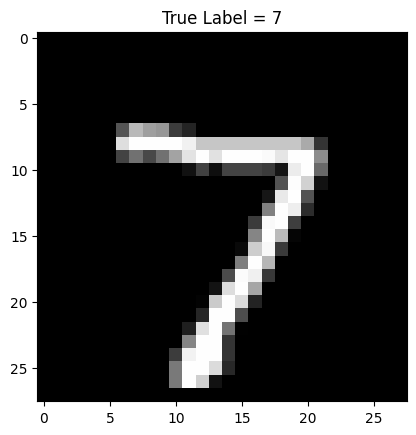

In [31]:
sample = X_test[0]

plt.imshow(
    sample.reshape(28,28),
    cmap='gray'
)

plt.title(
    f"True Label = {y_test[0]}"
)

plt.show()

In [35]:
from tensorflow.keras.models import Model

layer_outputs = [
    cnn.layers[0].output,
    cnn.layers[2].output
]

activation_model = Model(
    inputs=cnn.inputs,
    outputs=layer_outputs
)

activations = activation_model.predict(
    sample.reshape(1,28,28,1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


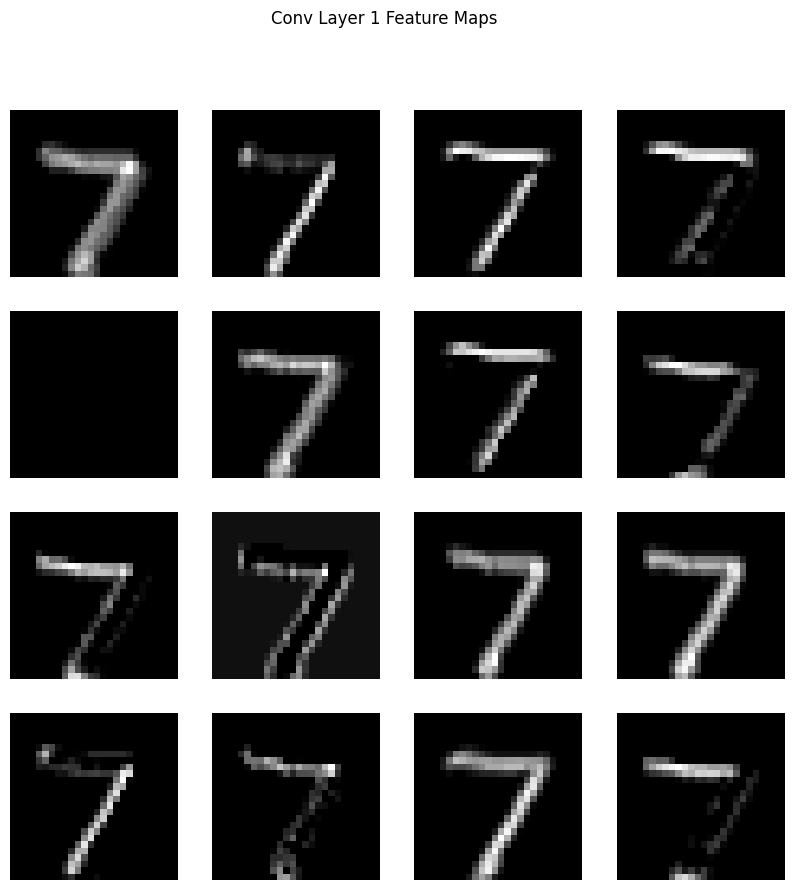

In [36]:
feature_maps = activations[0]

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        feature_maps[0,:,:,i],
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle(
    "Conv Layer 1 Feature Maps"
)

plt.show()

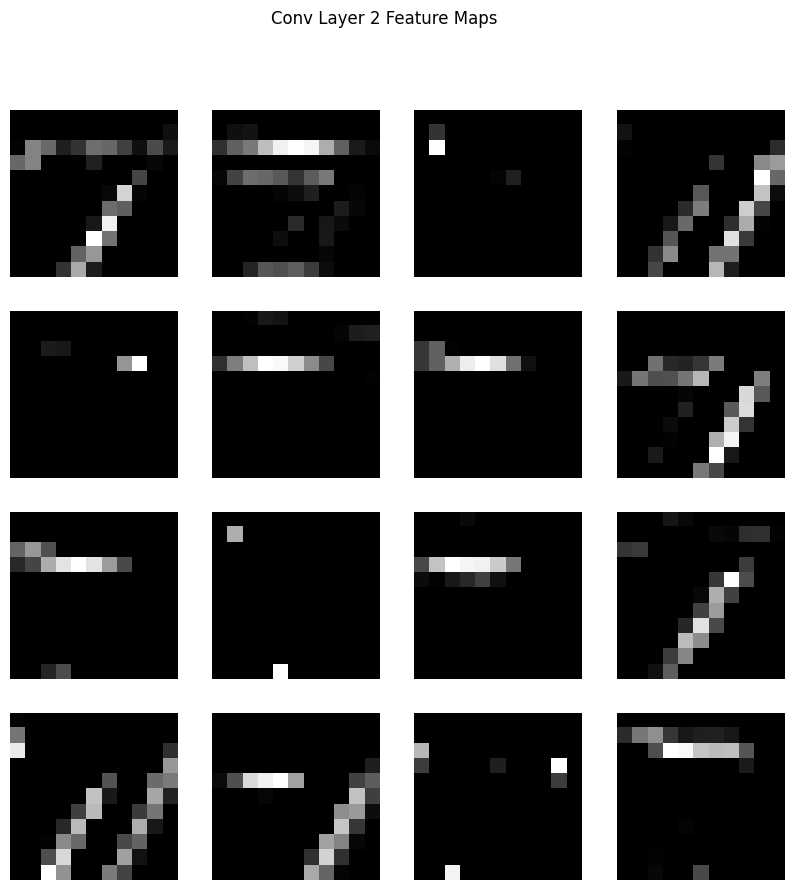

In [37]:
feature_maps = activations[1]

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        feature_maps[0,:,:,i],
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle(
    "Conv Layer 2 Feature Maps"
)

plt.show()

In [38]:
cnn_params = cnn.count_params()

fnn_params = fnn.count_params()

print("CNN Parameters :", cnn_params)

print("FNN Parameters :", fnn_params)

CNN Parameters : 225034
FNN Parameters : 109386


In [39]:
cnn_params = cnn.count_params()

fnn_params = fnn.count_params()

print("CNN Parameters :", cnn_params)

print("FNN Parameters :", fnn_params)

CNN Parameters : 225034
FNN Parameters : 109386
